**1. importing dependencies**

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

**2. Data Loading and Understanding**

In [62]:
# load teh csv data to a pandas dataframe
df = pd.read_csv("Telco-Customer-Churn.csv")

In [63]:
df.shape

(7043, 21)

In [64]:
pd.set_option("display.max_columns", None)

In [65]:
#using sample() instead of head() to view random rows, since head() only show the first few rows 
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5867,2428-HYUNX,Male,1,Yes,No,44,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.35,847.25,No
543,1342-JPNKI,Male,0,No,No,10,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),86.05,834.1,Yes
6086,0916-KNFAJ,Male,0,Yes,No,61,Yes,Yes,DSL,Yes,No,Yes,No,No,Yes,Two year,Yes,Mailed check,69.90,4226.7,No
851,2252-NKNSI,Male,0,No,Yes,52,Yes,Yes,DSL,Yes,Yes,No,Yes,Yes,Yes,Two year,Yes,Mailed check,85.15,4461.85,No
1133,3156-QLHBO,Male,0,No,Yes,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.25,48.35,No
2623,3130-ICDUP,Female,0,No,Yes,2,Yes,Yes,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Credit card (automatic),80.55,188.1,No
3055,0617-FHSGK,Male,0,No,Yes,49,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Credit card (automatic),75.20,3678.3,Yes
4510,6368-NWMCE,Female,0,No,No,38,Yes,Yes,DSL,No,Yes,No,Yes,No,Yes,Month-to-month,No,Credit card (automatic),68.15,2656.3,No
2062,7996-MHXLW,Female,0,No,No,66,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.15,1683.6,No
3371,4946-EDSEW,Female,0,Yes,Yes,11,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.25,180.3,Yes


In [66]:
# dropping customerID column as this is not required for modelling
df = df.drop(columns=["customerID"])

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [68]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [69]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [70]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

In [71]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [72]:
# checking the class distribution of target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Insights:**
1. Customer ID removed as it is not required for modelling
2. No missing values in the dataset
3. TotalCharges DType converted from object to float64 as it has numerical values
3. Missing values in the TotalCharges column were replaced with 0
4. Class imbalance identified in the target

**3. Exploratory Data Analysis (EDA)**

**Numerical Features - Analysis**

In [73]:
def plot_histogram(df, col):
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"distribution of {col}")
    
    # calculate the mean and median values for the columns
    col_mean = df[col].mean()
    col_median = df[col].median()

    # add vertical lines for mean and median
    plt.axvline(col_mean, color='red', label = "Mean")
    plt.axvline(col_median, color='green', label = "Median")
    
    plt.legend()
    
    plt.show()


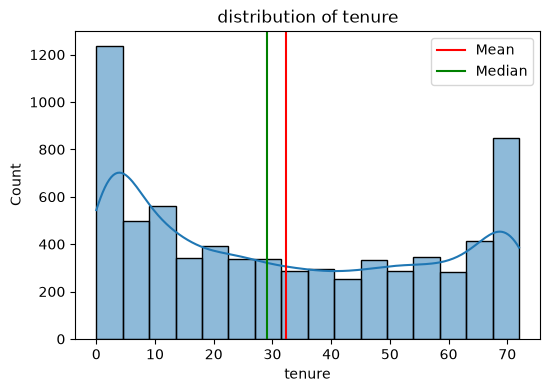

In [74]:
plot_histogram(df, "tenure")

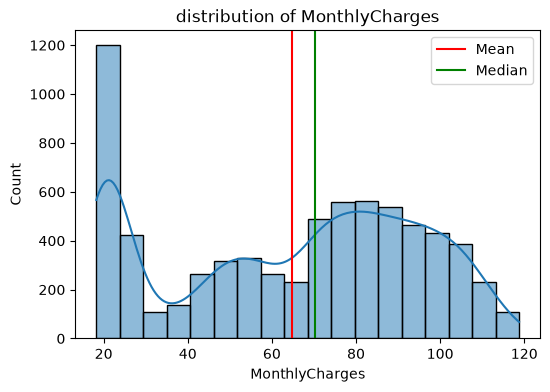

In [75]:
plot_histogram(df, "MonthlyCharges")

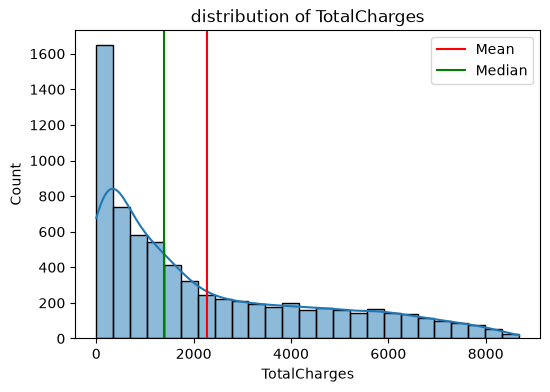

In [76]:
plot_histogram(df, "TotalCharges")

In [77]:
def plot_boxplot(df, col):
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"box plot of {col}")
    plt.ylabel(col)
    plt.show

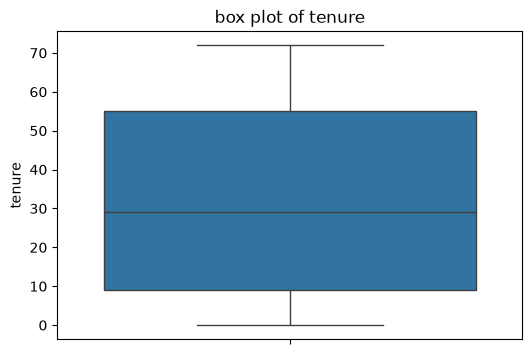

In [78]:
plot_boxplot(df, "tenure")

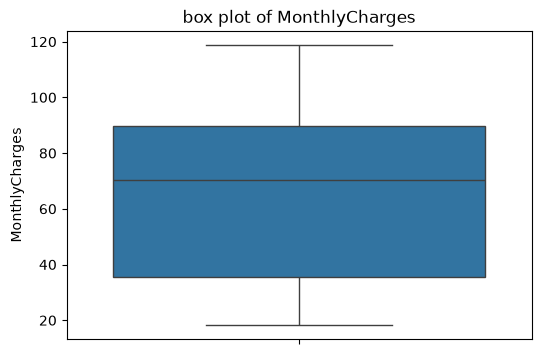

In [79]:
plot_boxplot(df, "MonthlyCharges")

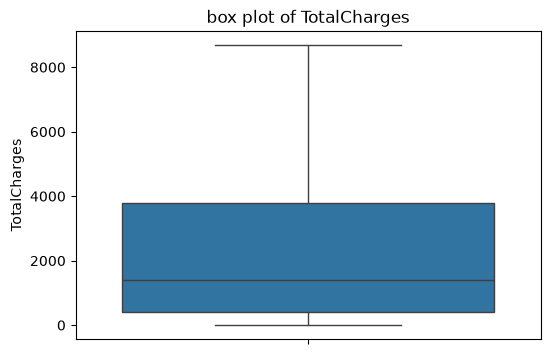

In [80]:
plot_boxplot(df, "TotalCharges")

**categorical Features - Analysis**

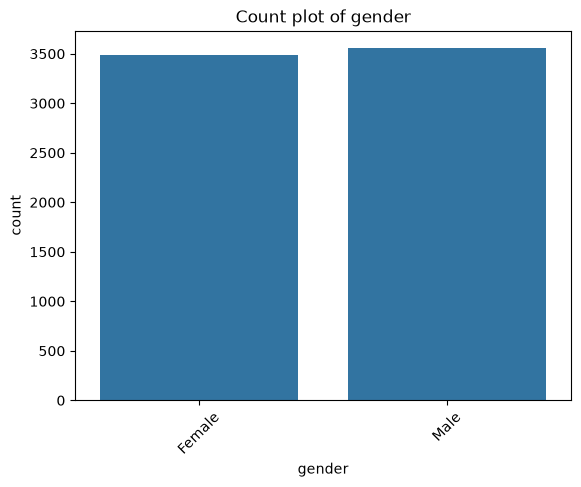

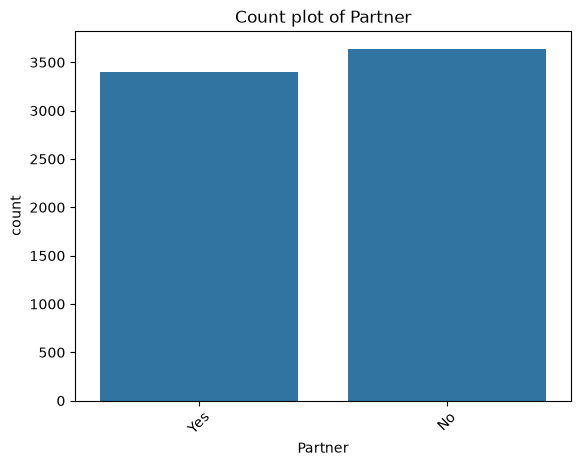

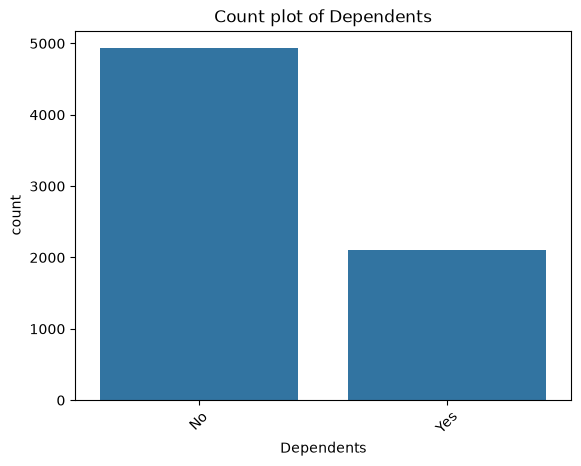

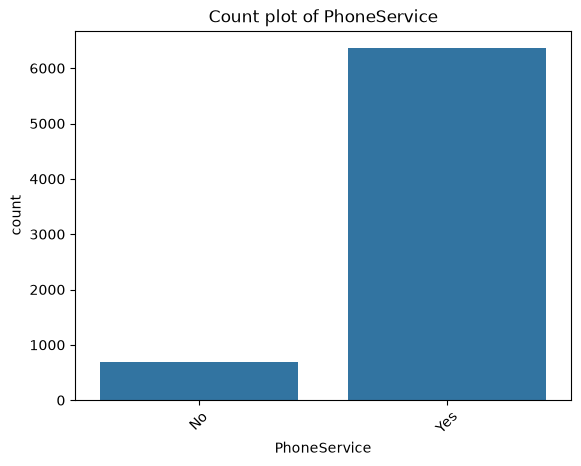

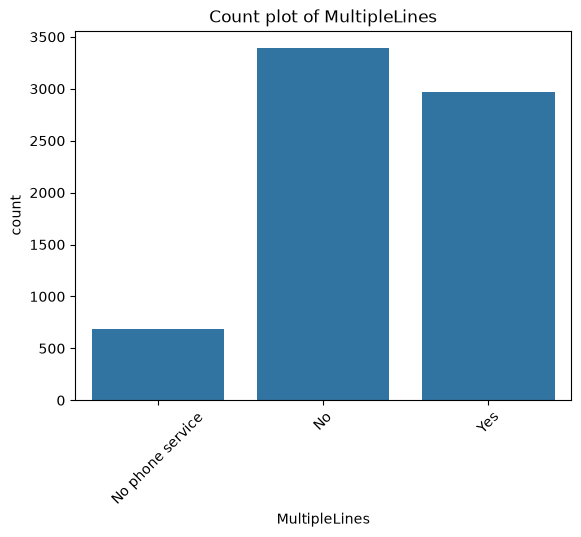

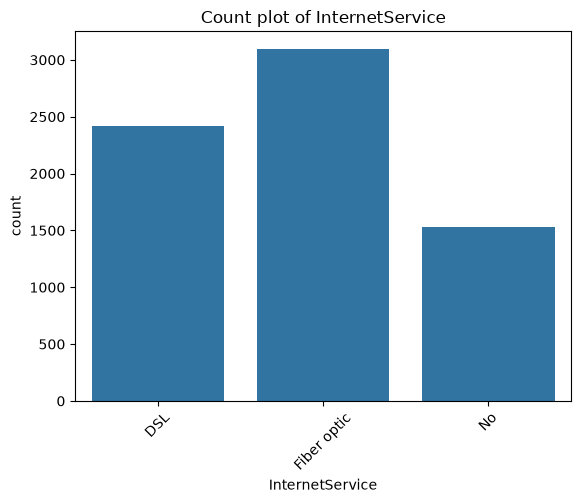

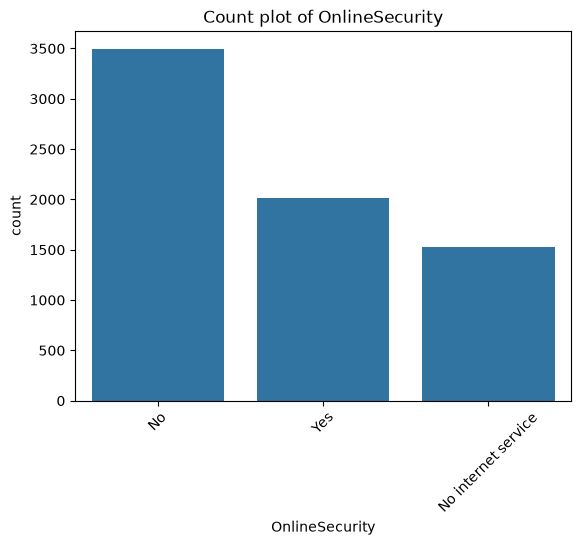

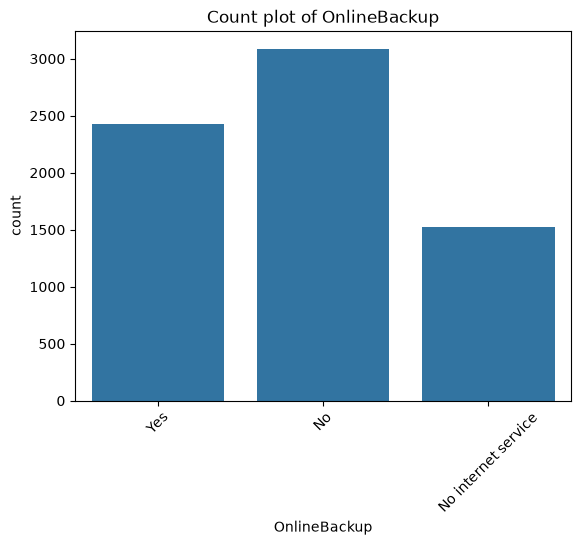

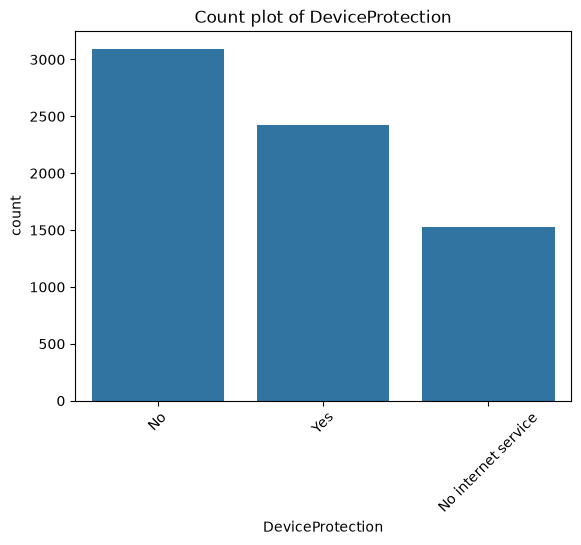

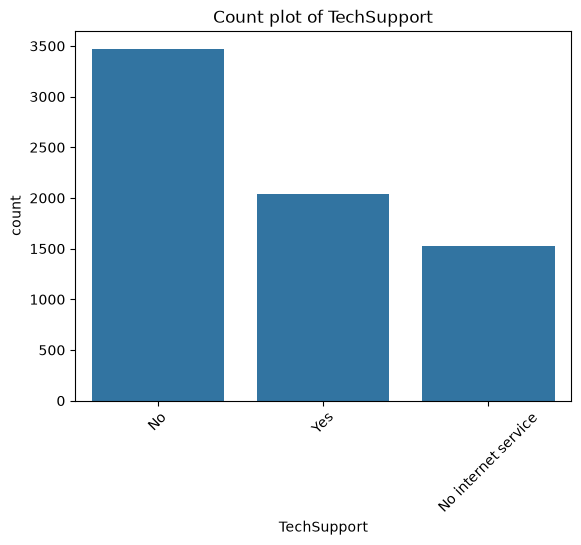

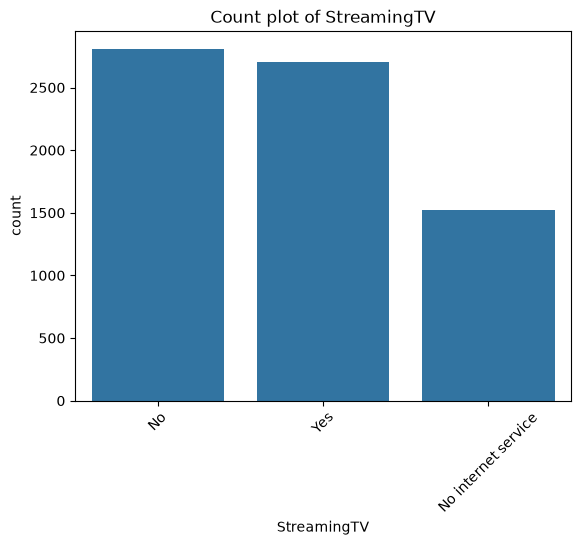

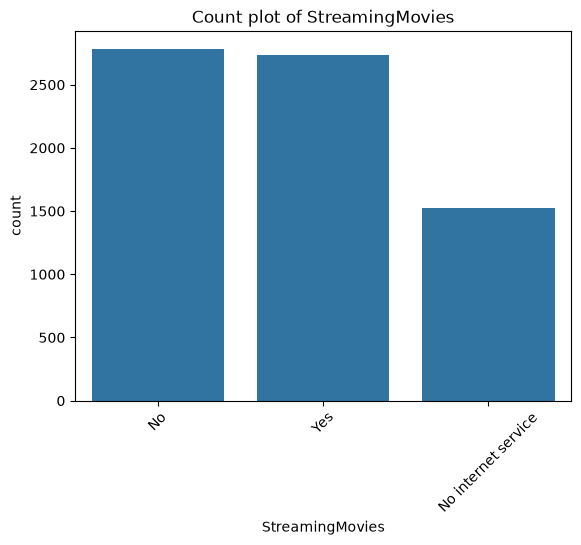

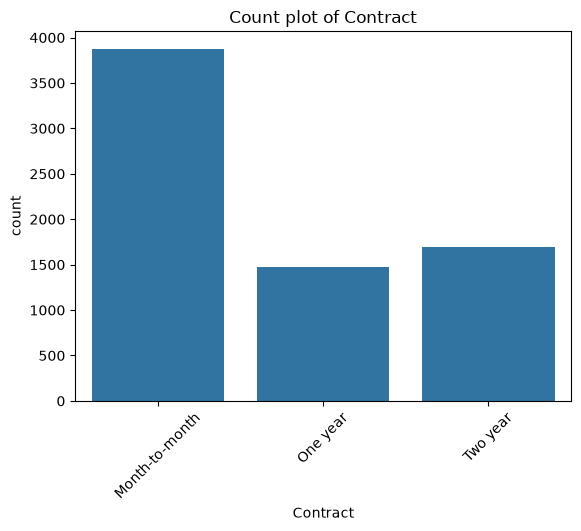

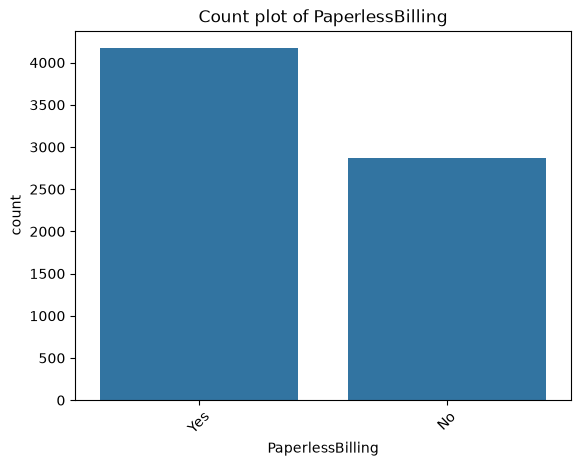

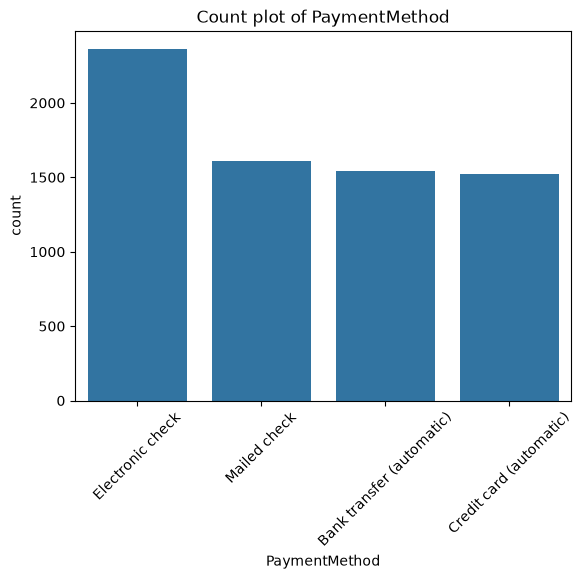

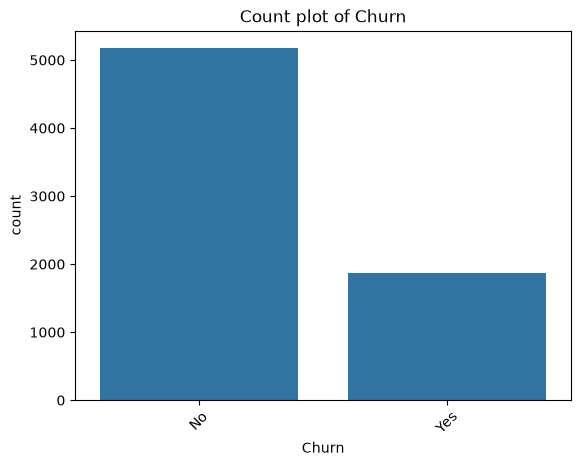

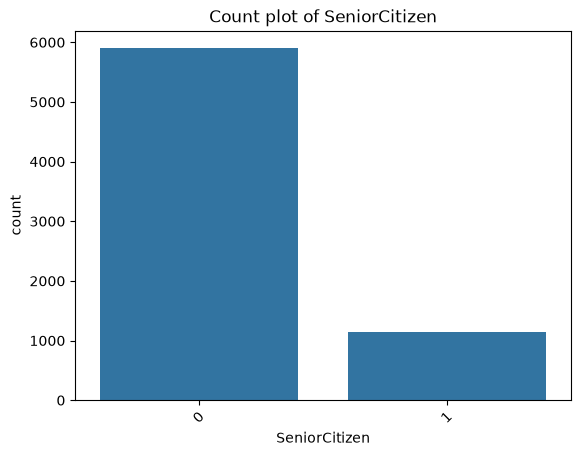

In [81]:
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
cat_cols.append("SeniorCitizen")

for col in cat_cols:
    sns.countplot(x=df[col])
    plt.title(f"Count plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

**Bivariate Analysis**

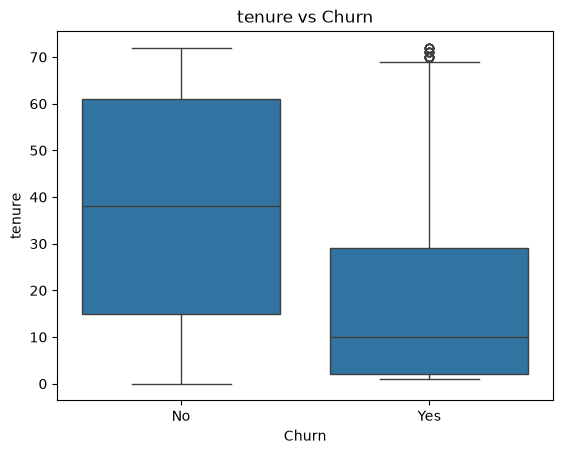

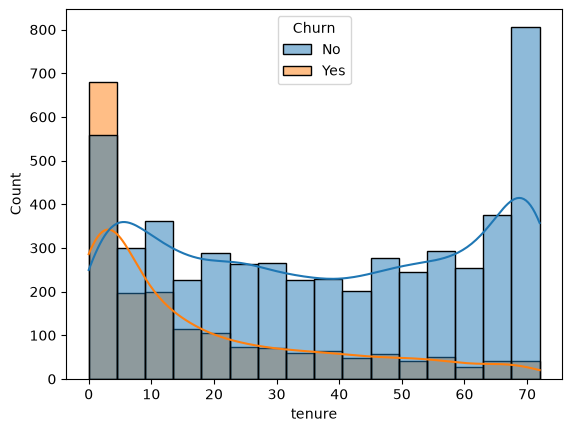

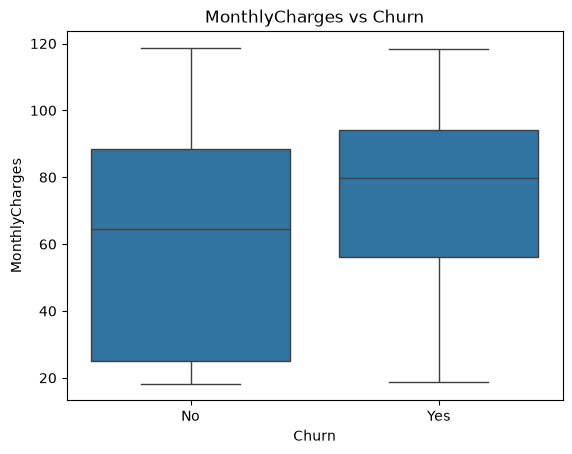

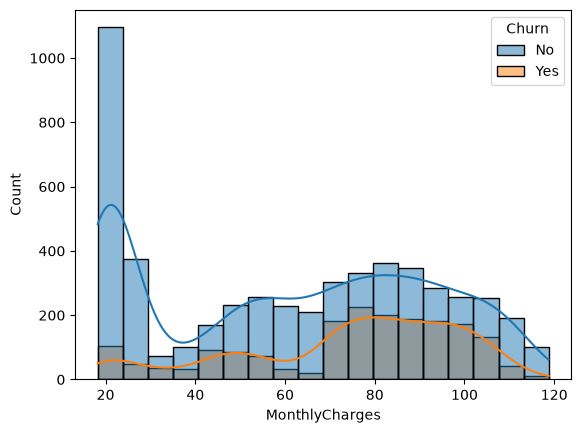

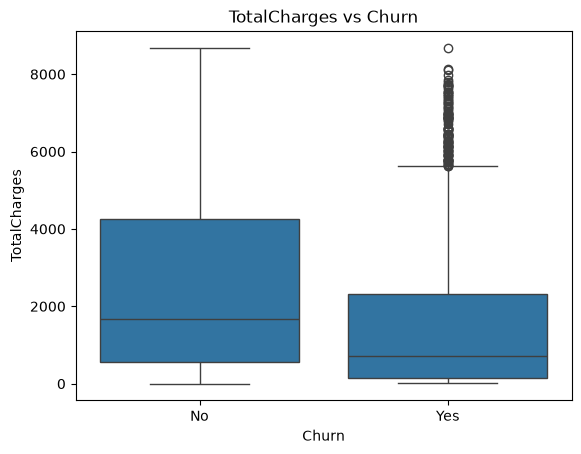

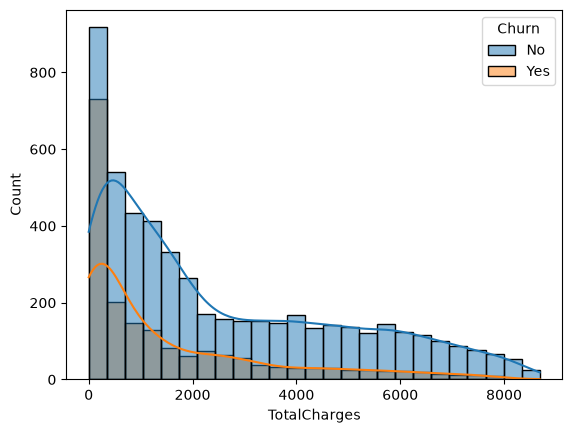

In [82]:
# numerical vs churn 
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

    sns.histplot(data=df, x=col, hue="Churn", kde=True)
    plt.show()

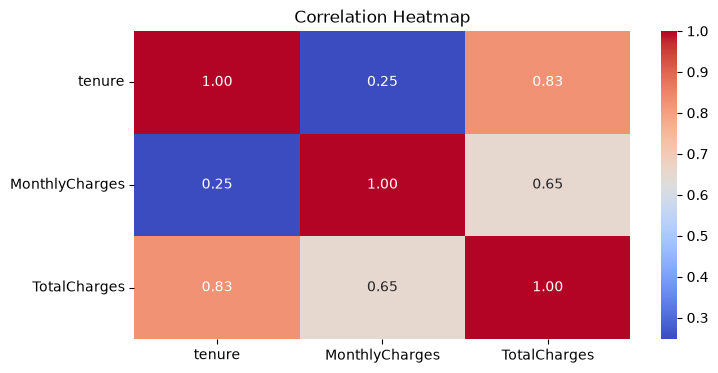

In [83]:
# numerical vs numerical
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**4. Data Preprocessing**

In [84]:
# printing the unique values in all the columns

numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50)

gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup <ArrowStringArray>
['Yes', 

In [85]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
399,Female,0,Yes,Yes,23,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.05,415.1,No
5049,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.2,Yes
227,Female,0,Yes,No,1,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Mailed check,55.20,55.2,Yes
1940,Male,0,No,No,63,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,One year,No,Electronic check,71.50,4576.3,No
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,No


In [86]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

In [87]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state =42)

X_train.shape, X_test.shape

((5634, 19), (1409, 19))

In [88]:
# label encoding for target column 

y_train = y_train.map({"No" : 0, "Yes" : 1})
y_test = y_test.map({"No" : 0, "Yes" : 1})

In [89]:
# label encoding for binary columns

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

In [90]:
# one-hot encoding for multi-category columns 

multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

ohe = OneHotEncoder(drop='first', sparse_output = False, handle_unknown = 'ignore')

X_train_ohe = ohe.fit_transform(X_train[multi_cols])
X_test_ohe = ohe.transform(X_test[multi_cols])

ohe_cols = ohe.get_feature_names_out(multi_cols)

X_train_ohe_df = pd.DataFrame(X_train_ohe, columns = ohe_cols, index = X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns = ohe_cols, index = X_test.index)\

X_train = pd.concat([X_train.drop(columns = multi_cols), X_train_ohe_df], axis =1)
X_test = pd.concat([X_test.drop(columns = multi_cols), X_test_ohe_df], axis =1)

Synthetic Minority Oversampling TEchnique (SMOTE)

In [91]:
smote = SMOTE(random_state = 42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


In [92]:
# scaling 

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train[num_cols].describe().round(4)

,tenure,MonthlyCharges,TotalCharges
count,8276.0000,8276.0000,8276.0000
mean,-0.0000,0.0000,0.0000
std,1.0001,1.0001,1.0001
min,-1.1713,-1.7332,-0.9473
25%,-0.9614,-0.7893,-0.8118
50%,-0.2479,0.2347,-0.4017
75%,0.8434,0.7975,0.5634
max,1.8508,1.7615,3.0241


**5. Model Training**

In [93]:
# Dictionary of models
models = {
    "Logistic Regression (L2)": LogisticRegression(random_state=42),
    "Logistic Regression (L1)": LogisticRegression(l1_ratio=1, solver="liblinear", C=1.0 , random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

In [94]:
# dictionary to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} ")
  scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Logistic Regression (L2) 
Logistic Regression (L2) cross-validation accuracy: 0.79
----------------------------------------------------------------------
Training Logistic Regression (L1) 
Logistic Regression (L1) cross-validation accuracy: 0.78
----------------------------------------------------------------------
Training Decision Tree 
Decision Tree cross-validation accuracy: 0.80
----------------------------------------------------------------------
Training Random Forest 
Random Forest cross-validation accuracy: 0.84
----------------------------------------------------------------------
Training XGBoost 
XGBoost cross-validation accuracy: 0.83
----------------------------------------------------------------------


In [95]:
cv_scores

{'Logistic Regression (L2)': array([0.73309179, 0.75468278, 0.81510574, 0.80241692, 0.81993958]),
 'Logistic Regression (L1)': array([0.73309179, 0.75468278, 0.81510574, 0.80302115, 0.81873112]),
 'Decision Tree': array([0.69263285, 0.70574018, 0.85861027, 0.87492447, 0.87794562]),
 'Random Forest': array([0.70048309, 0.74561934, 0.91903323, 0.91540785, 0.92024169]),
 'XGBoost': array([0.68115942, 0.73534743, 0.91722054, 0.9081571 , 0.91601208])}

**6. Model Evaluation**

In [96]:
rfc = RandomForestClassifier(random_state=42)

In [97]:
rfc.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [98]:
# evaluate on test data
y_test_pred = rfc.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.7913413768630234
Confsuion Matrix:
 [[918 118]
 [176 197]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.53      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [99]:
XGB = XGBClassifier(random_state=42)

In [100]:
XGB.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [101]:
# evaluate on test data
y_test_pred2 = XGB.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred2))
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred2))
print("Classification Report:\n", classification_report(y_test, y_test_pred2))

Accuracy Score:
 0.7913413768630234
Confsuion Matrix:
 [[908 128]
 [166 207]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86      1036
           1       0.62      0.55      0.58       373

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.79      0.79      0.79      1409



Model chosen: XGBoost. Random Forest had higher CV accuracy (84% vs 83%), but both scored the same on test accuracy (79%). Since recall matters more for churn, XGBoost wins with better recall (0.55 vs 0.53) and F1-score (0.58 vs 0.57), so it was selected as the final model.

In [111]:
# save the trained model as a pickle file
model_data = {"model": XGB, "features_names": X_train.columns.tolist()}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

**7. Load the saved  model and  build a Predictive System**

In [112]:
print(list(encoders.keys()))

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


In [114]:
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)   

with open("onehot_encoder.pkl", "wb") as f:
    pickle.dump(ohe, f)  

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [116]:
with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)
loaded_model = model_data["model"]
model_feature_names = model_data["features_names"]

with open("onehot_encoder.pkl", "rb") as f:
    ohe = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

In [117]:
def predict_churn(new_customer: dict):
    df_new = pd.DataFrame([new_customer])

    binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
    for col in binary_cols:
        df_new[col] = encoders[col].transform(df_new[col])

    multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                  "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                  "Contract", "PaymentMethod"]
    ohe_array = ohe.transform(df_new[multi_cols])
    ohe_cols = ohe.get_feature_names_out(multi_cols)
    ohe_df = pd.DataFrame(ohe_array, columns=ohe_cols, index=df_new.index)
    df_new = pd.concat([df_new.drop(columns=multi_cols), ohe_df], axis=1)

    num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
    df_new[num_cols] = scaler.transform(df_new[num_cols])

    df_new = df_new.reindex(columns=model_feature_names, fill_value=0)

    prediction = loaded_model.predict(df_new)[0]
    probability = loaded_model.predict_proba(df_new)[0][1]
    return ("Churn" if prediction == 1 else "No Churn"), probability

In [120]:
new_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 5, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 85.5, "TotalCharges": 425.0
}

result, prob = predict_churn(new_customer)
print(f"Prediction: {result} (probability: {prob:.2%})")

Prediction: Churn (probability: 67.88%)
